## MVP ANA - Semantic Frequency Analysis of Brazilian Legal Documents

### Project Overview

This notebook implements a full NLP pipeline that transforms raw PDF legal documents into structured semantic frequency statistics. Starting from scanned or digital court documents, the pipeline extracts sentences, normalises encoding artifacts, removes boilerplate, segments into sentences, normalises citations, and clusters semantically similar sentences using UMAP + HDBSCAN. Case type labels are assigned post-hoc to each cluster using regex applied to the cluster's representative sentence.

### Domain Context: Brazilian Legal Document Analysis

#### Core Domain Definition
Brazilian court documents (petições, acórdãos, sentenças, despachos) address a wide variety of criminal case types. Clustering all sentences together and labelling clusters post-hoc via regex allows pattern discovery across the full corpus, revealing recurring arguments, standard precedents, and emergent legal themes that may not match any predefined case type.

### Problem Definition: Semantic Frequency Analysis Pipeline

#### Problem Statement
Develop a pipeline that ingests Brazilian legal PDFs and outputs frequency statistics of semantically grouped sentences per criminal case type. The statistics surface recurring thematic clusters, enabling researchers and practitioners to identify dominant legal arguments, frequently cited precedents, and standard procedural language at scale.

#### Technical Requirements
- **Problem Type**: Unsupervised clustering with post-hoc case type labeling
- **Input Format**: Brazilian legal PDFs (digital or scanned)
- **Output Format**: Cluster frequency tables, similarity matrices, and static visualizations
- **Difficulty Level**: High — multilingual NLP, OCR, domain-specific abbreviations, sparse legal corpora

#### Data Landscape
The pipeline processes:
- Raw PDF pages (digital text layer or scanned images)
- 768-dim BERT embeddings per sentence
- UMAP 5-dim projection across all sentences
- HDBSCAN cluster assignments and membership probabilities
- Post-hoc case type labels per cluster (regex on representative sentence)

### References

- **Architecture Decision Record**: [semantic_analysis_solution_adr.docx](docs/semantic_analysis_solution_adr.docx) — Documents the pipeline design, technology choices, and rationale for each step;
- **BERTimbau model**: [neuralmind/bert-base-portuguese-cased](https://huggingface.co/neuralmind/bert-base-portuguese-cased) — Portuguese BERT used for sentence embeddings as a substitute for LegalBERT-pt;

---

This notebook serves as the primary entry point for the MVP ANA implementation. Each pipeline step is self-contained and its output is checkpointed to disk, allowing individual steps to be re-run without re-executing expensive upstream operations.

### Import Libraries

Installation and import of all required libraries. Warning verbosity is suppressed globally to keep notebook output clean.

In [1]:
%pip install pdfplumber pytesseract Pillow ftfy scikit-learn umap-learn hdbscan transformers torch numpy matplotlib bertopic faiss-cpu

import warnings
import logging
import importlib
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add pipeline scripts to Python path
scripts_path = Path("./pipeline/scripts")
if str(scripts_path.resolve()) not in sys.path:
    sys.path.insert(0, str(scripts_path.resolve()))

# Import and reload all pipeline step modules to pick up changes without kernel restart
import pipeline_step
import pipeline_manager
import step_0_pdf_reader
import step_1_encoding_normalizer
import step_2_boilerplate_remover
import step_3_sentence_segmenter
import step_4_citation_normalizer
import step_5_embedding_generator
import step_6_bertopic
import step_7_statistics_generator
import step_8_visualizer
import step_9_xml_exporter
import step_10_search_index

importlib.reload(pipeline_step)
importlib.reload(pipeline_manager)
importlib.reload(step_0_pdf_reader)
importlib.reload(step_1_encoding_normalizer)
importlib.reload(step_2_boilerplate_remover)
importlib.reload(step_3_sentence_segmenter)
importlib.reload(step_4_citation_normalizer)
importlib.reload(step_5_embedding_generator)
importlib.reload(step_6_bertopic)
importlib.reload(step_7_statistics_generator)
importlib.reload(step_8_visualizer)
importlib.reload(step_9_xml_exporter)
importlib.reload(step_10_search_index)

from pipeline_step import PipelineStep
from pipeline_manager import PipelineManager
from step_0_pdf_reader import PdfReader, PdfReaderInput
from step_1_encoding_normalizer import EncodingNormalizer
from step_2_boilerplate_remover import BoilerplateRemover
from step_3_sentence_segmenter import SentenceSegmenter
from step_4_citation_normalizer import CitationNormalizer
from step_5_embedding_generator import EmbeddingGenerator
from step_6_bertopic import BerTopicStep
from step_7_statistics_generator import StatisticsGenerator
from step_8_visualizer import Visualizer
from step_9_xml_exporter import XmlExporter
from step_10_search_index import SumulaSearchIndex

# Suppress warnings and verbose loggers
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(name)s - %(levelname)s - %(message)s")
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("umap").setLevel(logging.ERROR)
logging.getLogger("numba").setLevel(logging.ERROR)

Note: you may need to restart the kernel to use updated packages.


2026-03-17 15:23:30.700500: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Pipeline Configuration

All tunable parameters are defined here as a single source of truth. `random_seed` propagates to every step that requires stochastic reproducibility (UMAP, any future fine-tuned model).

In [2]:
# Global parameters
random_seed = 42  # PARAMETER: single source of randomness for all components

# Step 0
pdf_path = Path("./datasets/Súmulas - STJ.pdf")  # PARAMETER: path to the input PDF

ocr_fallback = True  # PARAMETER: attempt OCR for scanned pages
min_page_text = 50  # PARAMETER: minimum characters per page before OCR fallback

# Step 2
tfidf_threshold = 0.92  # PARAMETER: cosine similarity threshold for boilerplate detection

# Step 3
min_sentence_tokens = 5  # PARAMETER: minimum tokens for a sentence to be retained

# Step 5
embedding_batch_size = 16  # PARAMETER: sentences per inference batch
max_tokens = 512  # PARAMETER: BERT context window
overlap_tokens = 64  # PARAMETER: sliding window overlap

# Step 6
bertopic_n_neighbors = 15  # PARAMETER: UMAP neighborhood size for BERTopic
bertopic_min_cluster = 2   # PARAMETER: HDBSCAN minimum cluster size - minimum valid value
bertopic_top_words = 5     # PARAMETER: number of keywords per topic label

# Checkpoint directory
checkpoint_dir = Path("./pipeline/checkpoints")

print(f"Random seed: {random_seed}")
print(f"Input PDF: {pdf_path}")
print(f"Checkpoint dir: {checkpoint_dir}")

Random seed: 42
Input PDF: datasets/Súmulas - STJ.pdf
Checkpoint dir: pipeline/checkpoints


### Build Pipeline

Instantiate all step processors and register them with the PipelineManager. The manager will execute each step in order, saving outputs to disk so that expensive steps can be skipped on subsequent runs.

In [3]:
steps = [
    PdfReader(min_text_length=min_page_text),
    EncodingNormalizer(),
    BoilerplateRemover(tfidf_threshold=tfidf_threshold),
    SentenceSegmenter(min_tokens=min_sentence_tokens),
    CitationNormalizer(),
    EmbeddingGenerator(
        max_tokens=max_tokens,
        overlap_tokens=overlap_tokens,
        batch_size=embedding_batch_size,
    ),
    BerTopicStep(
        n_neighbors=bertopic_n_neighbors,
        min_cluster_size=bertopic_min_cluster,
        top_n_words=bertopic_top_words,
        random_state=random_seed,
    ),
    StatisticsGenerator(),
]
manager = PipelineManager(checkpoint_dir=checkpoint_dir, steps=steps)
status = manager.checkpoint_status()
print("Checkpoint status:")
for step_num, exists in status.items():
    print(f"  Step {step_num:2d}: {'cached' if exists else 'pending'}")

Checkpoint status:
  Step  0: cached
  Step  1: cached
  Step  2: cached
  Step  3: cached
  Step  4: cached
  Step  5: cached
  Step  6: pending
  Step  7: pending


**Step 0. Read Text from PDF**

pdfplumber extracts the digital text layer directly from the PDF. When a page contains fewer than `min_page_text` characters (indicating a scanned image page), Tesseract OCR is invoked on a 300 DPI rasterisation. This dual approach handles mixed-mode documents common in Brazilian court archives.

In [4]:
pdf_input = PdfReaderInput(
    pdf_path=pdf_path,
    ocr_fallback=ocr_fallback,
    min_text_length=min_page_text,
)
step0_output = manager.run_step(0, pdf_input)
print(f"Pages: {step0_output.page_count}")
print(f"OCR pages: {step0_output.ocr_pages}")
print(f"Text length: {len(step0_output.raw_text):,} characters")
print(f"Preview: {step0_output.raw_text[:300]!r}")

pipeline.manager - INFO - Step 0 loaded from checkpoint


Pages: 2642
OCR pages: []
Text length: 5,391,932 characters
Preview: 'SUMSÁRIO úmulas Organizadas por\nRamo do Direito\nSUMÁRIO\nDIREITO ADMINISTRATIVO - ÁGUA E ESGOTO 30\nSúmula 407 30\nSúmula 412 33\nDIREITO ADMINISTRATIVO - ANISTIA POLÍTICA 35\nSúmula 624 35\nSúmula 647 38\nDIREITO ADMINISTRATIVO - ATIVIDADE FARMACÊUTICA 43\nSúmula 120 43\nSúmula 275 46\nSúmula 413 50\nSúmula 5'


**Step 1. Encoding Normalization**

ftfy repairs mojibake and other encoding artifacts produced by legacy PDF generators (common in Brazilian public sector documents). NFC normalization unifies code-point representations so that subsequent regex and tokenisation steps behave deterministically. All replacements are logged for audit purposes.

In [5]:
step1_output = manager.run_step(1, step0_output)
print(f"Replacements applied: {len(step1_output.replacements)}")
if step1_output.replacements:
    print("Sample replacements:")
    for orig, fixed in step1_output.replacements[:5]:
        print(f"  {orig!r} → {fixed!r}")
print(f"Clean text length: {len(step1_output.clean_text):,} characters")

pipeline.manager - INFO - Step 1 loaded from checkpoint


Replacements applied: 0
Clean text length: 5,391,932 characters


**Step 2. Boilerplate Removal**

Legal documents contain recurring non-informative headers, footers, page numbers, and standard certification phrases. Regex patterns handle deterministic patterns. TF-IDF cosine similarity detects near-duplicate paragraphs that regex alone would miss (e.g., repeated court signatures). Content is replaced with `<BOILERPLATE>` rather than deleted to preserve positional context for downstream steps.

In [6]:
step2_output = manager.run_step(2, step1_output)
print(f"Segments replaced: {step2_output.removed_count}")
print(f"TF-IDF threshold used: {step2_output.tfidf_threshold}")
print(f"Filtered text length: {len(step2_output.filtered_text):,} characters")

pipeline.manager - INFO - Step 2 loaded from checkpoint


Segments replaced: 504
TF-IDF threshold used: 0.92
Filtered text length: 5,355,741 characters


**Step 3. Súmula Segmentation**

Each súmula block — from its header line (`Súmula N`) to the next súmula header — is extracted as a single semantic unit. This preserves the full context of each legal rule (header + body text) as one embedding input, providing BERTimbau with richer context than individual sentences. Segments shorter than `min_sentence_tokens` words are discarded. When no súmula boundaries are detected, the step falls back to double-newline paragraph splitting.

In [7]:
step3_output = manager.run_step(3, step2_output)
print(f"Sentences extracted: {step3_output.sentence_count:,}")
print("\nSample sentences:")
for i, sent in enumerate(step3_output.sentences[:3]):
    print(f"  [{i+1}] {sent[:120]!r}")

pipeline.manager - INFO - Step 3 loaded from checkpoint


Sentences extracted: 502

Sample sentences:
  [1] 'SUMÁRIO\nDIREITO ADMINISTRATIVO - ÁGUA E ESGOTO 30\nSúmula 407 30\nSúmula 412 33\nDIREITO ADMINISTRATIVO - ANISTIA POLÍTICA '
  [2] 'SÚMULA 412\nDIREITO ADMINISTRATIVO - ÁGUA E ESGOTO\nEnunciado: Órgão Julgador:\nA ação de repetição de indébito de tarifas '
  [3] 'SÚMULA 647\nDIREITO ADMINISTRATIVO - ANISTIA POLÍTICA\nEnunciado: Órgão Julgador:\nSão imprescritíveis as ações indenizatór'


**Step 4. Citation Normalization**

Legal citations (article references, process numbers, case references, súmula numbers) are idiosyncratic strings that would fragment embedding space without normalization. Each citation type is replaced by a typed token (`<ART_REF>`, `<PROC_NUM>`, `<CASE_REF>`, `<SUMULA_REF>`), enabling BERT to focus on rhetorical context. Original citations are stored in `citation_metadata` for reconstruction.

In [8]:
step4_output = manager.run_step(4, step3_output)
total_citations = sum(len(m) for m in step4_output.citation_metadata)
print(f"Sentences processed: {len(step4_output.sentences):,}")
print(f"Total citations normalized: {total_citations:,}")
print("\nSample normalized sentences:")
for i, (sent, meta) in enumerate(zip(step4_output.sentences[:3], step4_output.citation_metadata[:3])):
    print(f"  [{i+1}] {sent[:120]!r}")
    if meta:
        print(f"       Citations: {meta}")

pipeline.manager - INFO - Step 4 loaded from checkpoint


Sentences processed: 502
Total citations normalized: 863

Sample normalized sentences:
  [1] 'SUMÁRIO\nDIREITO ADMINISTRATIVO - ÁGUA E ESGOTO 30\nSúmula 407 30\nSúmula 412 33\nDIREITO ADMINISTRATIVO - ANISTIA POLÍTICA '
       Citations: {'<ART_REF>': 'artigo 4º,\nda Lei 6.528/78 e artigos 11 caput, 11, § 2º e 32 do Decreto nº 82', '<CASE_REF>': 'REsp 485842'}
  [2] 'SÚMULA 412\nDIREITO ADMINISTRATIVO - ÁGUA E ESGOTO\nEnunciado: Órgão Julgador:\nA ação de repetição de indébito de tarifas '
       Citations: {'<ART_REF>': 'ART. 177 DO CÓDIGO CIVIL DE 1916 [...] Os serviços públicos', '<CASE_REF>': 'REsp 1467148'}
  [3] 'SÚMULA 647\nDIREITO ADMINISTRATIVO - ANISTIA POLÍTICA\nEnunciado: Órgão Julgador:\nSão imprescritíveis as ações indenizatór'
       Citations: {'<ART_REF>': 'ART. 2. DO DECRETO N. 20.377/31, SEGUNDO O QUAL O COMÉRCIO', '<CASE_REF>': 'REsp 35351'}


**Step 5. Embedding with BERTimbau** [STEP CAN BE SKIPPED - re-runs use checkpoint]

BERTimbau (`neuralmind/bert-base-portuguese-cased`) is used as a practical substitute for LegalBERT-pt, which lacks a publicly available checkpoint. Mean pooling over all non-padding token hidden states produces a single 768-dim vector per sentence. Sentences exceeding 512 tokens are processed with a sliding window of `overlap_tokens` to prevent context loss at boundaries. This step now receives `CitationOutput` directly from Step 4.

In [9]:
step5_output = manager.run_step(5, step4_output)
print(f"Model: {step5_output.model_name}")
print(f"Embedding dimension: {step5_output.embedding_dim}")
print(f"Sentences embedded: {len(step5_output.embedded_sentences):,}")
sample_emb = step5_output.embedded_sentences[0].embedding
print(f"Sample vector norm: {float(np.linalg.norm(sample_emb)):.4f}")

pipeline.manager - INFO - Step 5 loaded from checkpoint


Model: neuralmind/bert-base-portuguese-cased
Embedding dimension: 768
Sentences embedded: 502
Sample vector norm: 8.4478


**Step 6. BERTopic Topic Modeling** [STEP CAN BE SKIPPED - re-runs use checkpoint]

BERTopic applies UMAP (2D, cosine metric, fixed `random_state`) to project the 768-dim BERTimbau embeddings, then HDBSCAN to discover density-based topic clusters, and finally c-TF-IDF to auto-generate keyword labels for each topic. Pre-computed embeddings from Step 5 are passed directly to avoid re-embedding. Sentences that do not belong to any dense group are labeled as noise (topic_id = -1). Topic labels are automatically generated from the most discriminating keywords per topic — no manual seed phrases required.

In [10]:
step6_output = manager.run_step(6, step5_output)
print(f"Total topics found: {step6_output.total_topics}")
print(f"Total noise sentences: {step6_output.noise_count:,}")
print("\nTopic labels discovered:")
for topic_id, label in sorted(step6_output.topic_labels.items()):
    sentences_in_topic = sum(1 for s in step6_output.topiced_sentences if s.topic_id == topic_id)
    print(f"  Topic {topic_id:3d}: {label} ({sentences_in_topic} sentences)")

manager._steps[8] = Visualizer(
    bertopic_output=step6_output,
    output_dir=Path("./pipeline/figures"),
)
manager._steps[9] = XmlExporter(
    bertopic_output=step6_output,
    results_dir=Path("./pipeline/results"),
)

pipeline.step_6 - INFO - Step 6 [BERTopic] started
pipeline.step_6 - INFO - Step 6 [BERTopic] completed in 12.55s
pipeline.manager - INFO - Checkpoint saved: pipeline/checkpoints/step_06.pkl


Total topics found: 142
Total noise sentences: 70

Topic labels discovered:
  Topic   0: Tributário > Icms > serviço_base cálculo_cálculo (10 sentences)
  Topic   1: Penal > Execução Penal > falta_falta grave_grave (9 sentences)
  Topic   2: Processual Civil > Recurso Especial > agravo_regimental (9 sentences)
  Topic   3: Processual Civil > Competência Da Justiça Federal > eleitoral_fundação_ferroviária (7 sentences)
  Topic   4: Administrativo > Água E Esgoto > deficiência_previdência_unilateral (7 sentences)
  Topic   5: Tributário > Iptu > contribuinte_indébito_imóvel (6 sentences)
  Topic   6: Bancário > Contrato Bancário > juros_taxa_capitalização (6 sentences)
  Topic   7: Tributário > Dpvat > prova_laudo_prova material (6 sentences)
  Topic   8: Processual Penal > Competência Da Justiça > militar_terceira seção (6 sentences)
  Topic   9: Bancário > Contrato Bancário > monetária_índice_correção (5 sentences)
  Topic  10: Civil > Desapropriação > indenização_dano_juros (5 sentenc

**Step 7. Generate Statistics**

For each non-noise BERTopic topic, the statistics step computes: sentence frequency, the representative sentence (highest cosine similarity to the centroid), non-representative sentence (lowest cosine similarity to centroid), and mean intra-topic cosine similarity. Topic labels come directly from BERTopic c-TF-IDF auto-generation — no BERTimbau re-inference or manual seed phrases are needed. Cross-topic centroid similarity reveals thematic overlap across the document.

In [11]:
step7_output = manager.run_step(7, step6_output)
print(f"Total topics analysed: {step7_output.total_clusters}")
print("\nTopic frequency (auto-labeled):")
for topic_label, count in sorted(step7_output.topic_frequency.items(), key=lambda x: -x[1]):
    bar = "#" * (count // max(1, max(step7_output.topic_frequency.values()) // 20))
    print(f"  {topic_label:<30} {count:5d}  {bar}")
print("\nTop 5 topics by frequency:")
top5 = sorted(step7_output.cluster_stats, key=lambda s: s.frequency, reverse=True)[:5]
for stats in top5:
    print(f"  [topic-{stats.topic_id} / {stats.topic_label}] freq={stats.frequency} intra_sim={stats.intra_similarity:.3f}")
    print(f"    Representative:     {stats.representative_sentence[:100]!r}")
    print(f"    Non-representative: {stats.non_representative_sentence[:100]!r}")

pipeline.step_7 - INFO - Step 7 [Statistics Generator] started
pipeline.step_7 - INFO - Step 7 [Statistics Generator] completed in 0.10s
pipeline.manager - INFO - Checkpoint saved: pipeline/checkpoints/step_07.pkl


Total topics analysed: 142

Topic frequency (auto-labeled):
  Tributário > Icms > serviço_base cálculo_cálculo    10  ##########
  Penal > Execução Penal > falta_falta grave_grave     9  #########
  Processual Civil > Recurso Especial > agravo_regimental     9  #########
  Processual Civil > Competência Da Justiça Federal > eleitoral_fundação_ferroviária     7  #######
  Administrativo > Água E Esgoto > deficiência_previdência_unilateral     7  #######
  Tributário > Iptu > contribuinte_indébito_imóvel     6  ######
  Bancário > Contrato Bancário > juros_taxa_capitalização     6  ######
  Tributário > Dpvat > prova_laudo_prova material     6  ######
  Processual Penal > Competência Da Justiça > militar_terceira seção     6  ######
  Bancário > Contrato Bancário > monetária_índice_correção     5  #####
  Civil > Desapropriação > indenização_dano_juros     5  #####
  Civil > Responsabilidade Civil > desapropriação_juros compostos_compostos     5  #####
  Penal > Lei Maria Da Penha > fogo

**Step 8. Visualization**

Three complementary static plots are produced:
1. **UMAP scatter** — 2D UMAP coordinates from BERTopic coloured by topic using tab20 colormap, noise sentences in gray
2. **Frequency bar chart** — sentence count per topic sorted descending
3. **Topic label frequency chart** — total sentence count per auto-generated topic label

All plots are saved to `./pipeline/figures/` for inclusion in reports.

pipeline.step_8 - INFO - Step 8 [Visualizer] started
pipeline.step_8 - INFO - Step 8 [Visualizer] completed in 7.00s
pipeline.manager - INFO - Checkpoint saved: pipeline/checkpoints/step_08.pkl


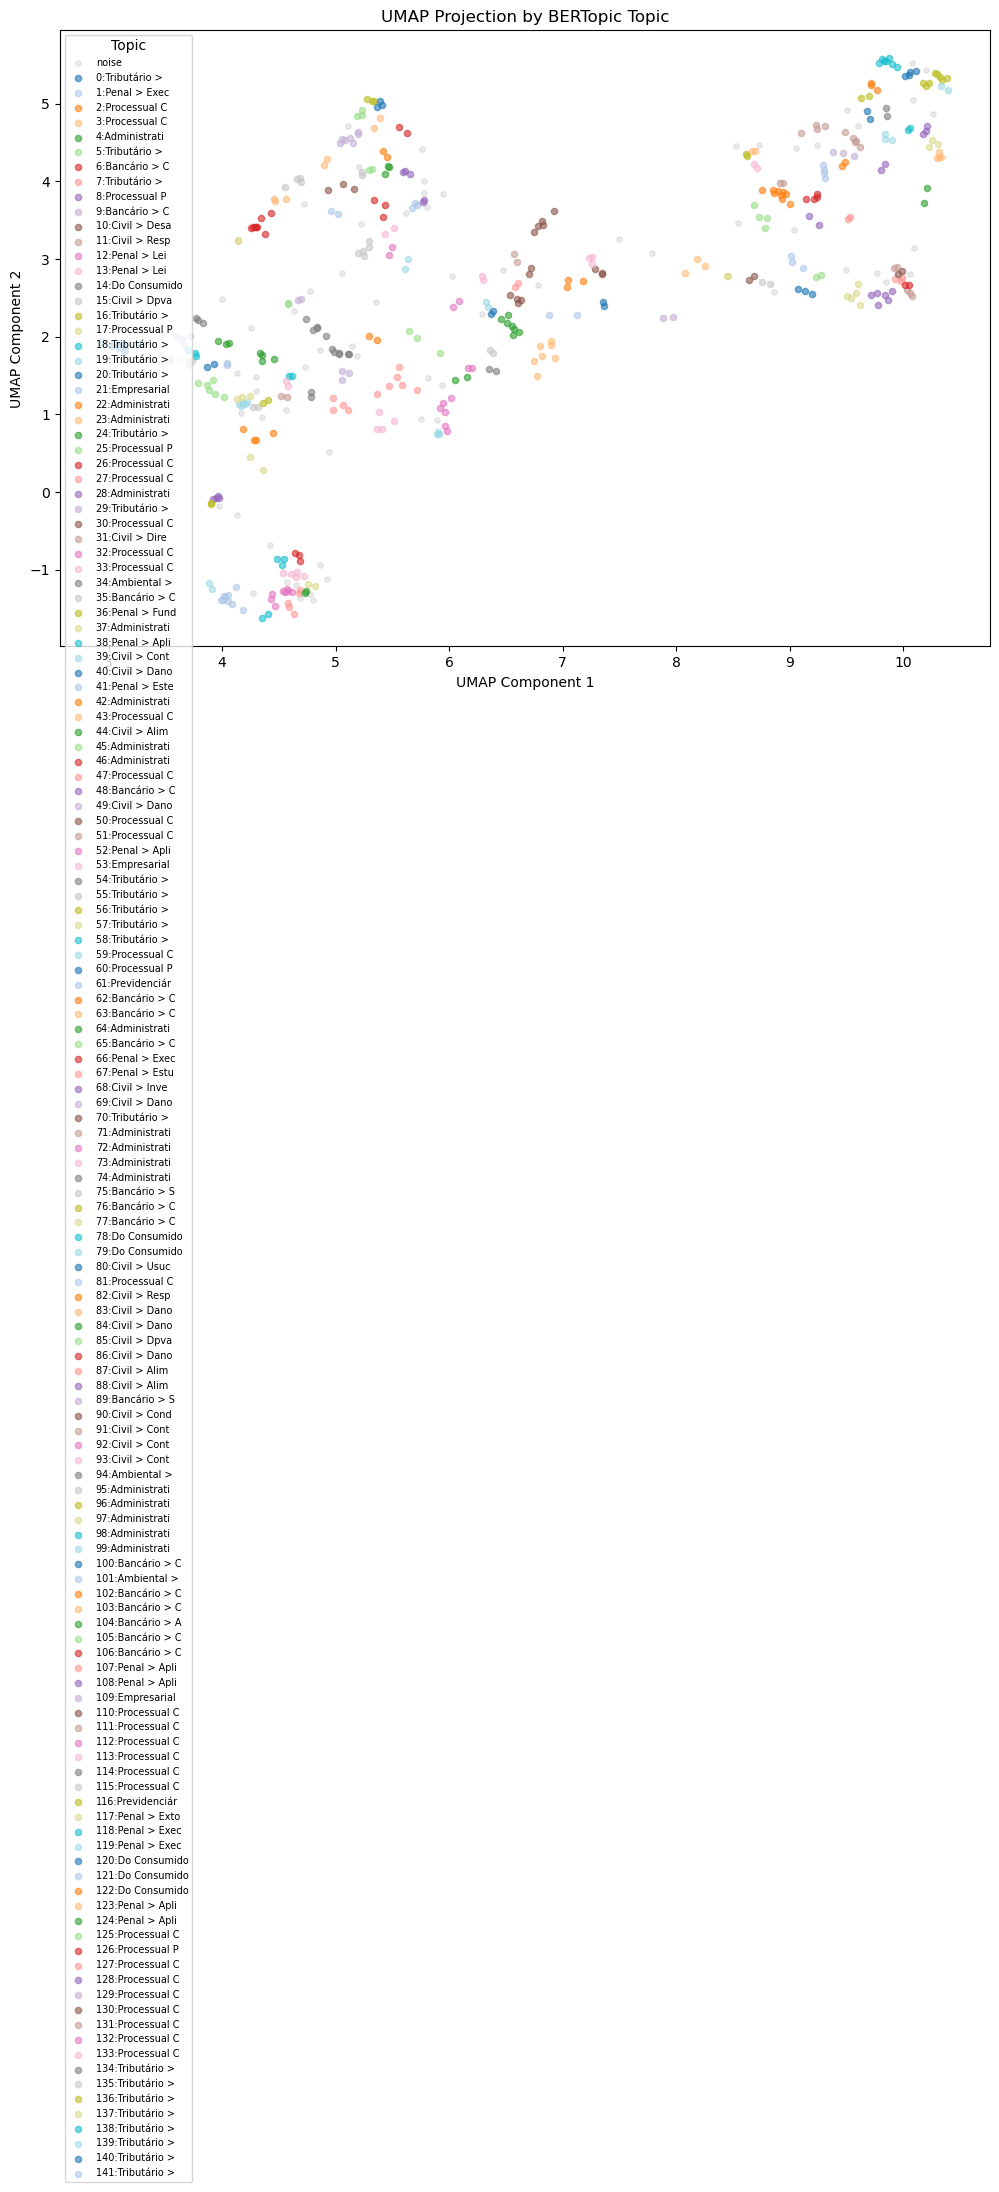

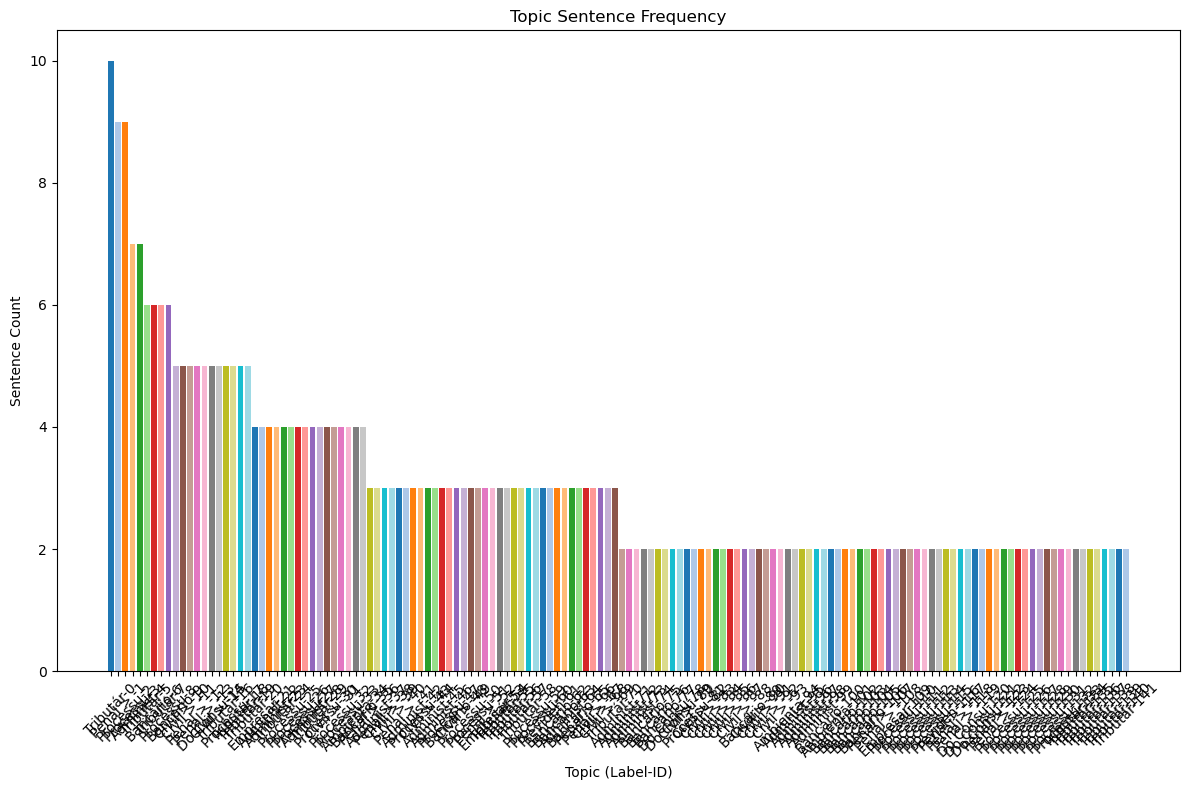

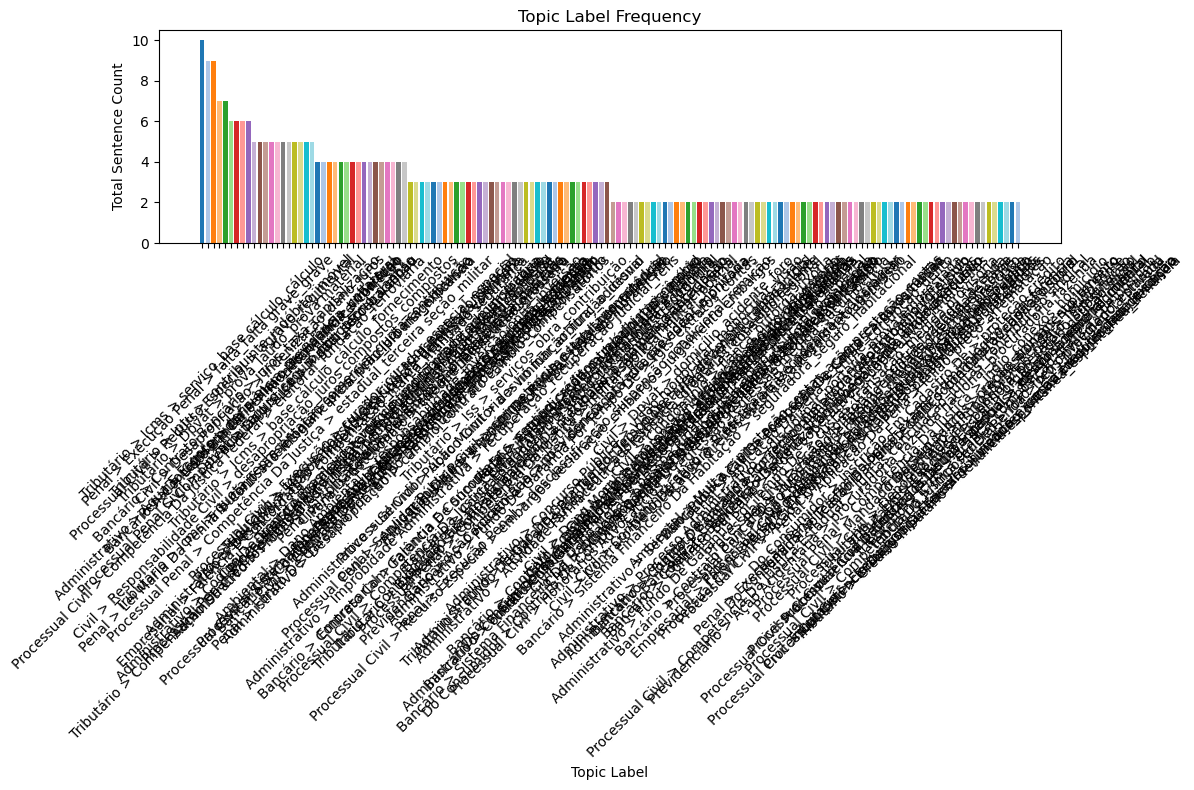


Figures saved to:
  pipeline/figures/umap_scatter.png
  pipeline/figures/frequency_bar.png
  pipeline/figures/topic_frequency.png


In [12]:
step8_output = manager.run_step(8, step7_output)
for fig in step8_output.figures:
    plt.show()
print("\nFigures saved to:")
for path in step8_output.saved_paths:
    print(f"  {path}")

**Step 9. XML Export**

Each non-noise BERTopic topic is exported to a dedicated XML file under `pipeline/results/`, named after its sanitized auto-generated topic label. Sentences carry `topic_id` and `probability` attributes and are sorted by topic_id then probability descending.

In [13]:
step9_output = manager.run_step(9, step7_output)
print(f"XML files exported to: {step9_output.results_dir}")
for topic_label, count in sorted(step9_output.sentence_counts.items(), key=lambda x: -x[1]):
    print(f"  {topic_label:<30} {count:5d} sentences")

pipeline.step_9 - INFO - Step 9 [XML Exporter] started
pipeline.step_9 - INFO - Step 9 [XML Exporter] completed in 0.06s
pipeline.manager - INFO - Checkpoint saved: pipeline/checkpoints/step_09.pkl


XML files exported to: pipeline/results
  Tributário > Icms > serviço_base cálculo_cálculo    10 sentences
  Penal > Execução Penal > falta_falta grave_grave     9 sentences
  Processual Civil > Recurso Especial > agravo_regimental     9 sentences
  Processual Civil > Competência Da Justiça Federal > eleitoral_fundação_ferroviária     7 sentences
  Administrativo > Água E Esgoto > deficiência_previdência_unilateral     7 sentences
  Tributário > Iptu > contribuinte_indébito_imóvel     6 sentences
  Bancário > Contrato Bancário > juros_taxa_capitalização     6 sentences
  Tributário > Dpvat > prova_laudo_prova material     6 sentences
  Processual Penal > Competência Da Justiça > militar_terceira seção     6 sentences
  Bancário > Contrato Bancário > monetária_índice_correção     5 sentences
  Civil > Desapropriação > indenização_dano_juros     5 sentences
  Civil > Responsabilidade Civil > desapropriação_juros compostos_compostos     5 sentences
  Penal > Lei Maria Da Penha > fogo_arma

### Frequency Table Summary

A structured frequency table consolidates all cluster statistics for downstream consumption (e.g., export to CSV, API response, or reporting dashboard).

In [14]:
import pandas as pd

topic_clusters: dict[str, list] = {}
for s in step7_output.cluster_stats:
    topic_clusters.setdefault(s.topic_label, []).append(s)

rows = []
for topic_label, clusters in sorted(topic_clusters.items()):
    top_clusters = sorted(clusters, key=lambda s: -s.frequency)[:2]
    total_frequency = sum(s.frequency for s in clusters)
    for i, s in enumerate(top_clusters):
        rows.append({
            "topic_label": topic_label if i == 0 else "",
            "total_frequency": total_frequency if i == 0 else "",
            "sample_sentence": s.representative_sentence[:120],
        })

df_topics = pd.DataFrame(rows)
print("Topic frequency table:")
print(df_topics.to_string(index=False))

Topic frequency table:
                                                                                         topic_label  total_frequency                                                                                                              sample_sentence
                                       Administrativo > Anistia Política > fiança_prorrogação_fiador                3 SÚMULA 603\n(SÚMULA CANCELADA)\nDIREITO BANCÁRIO - CONTRATO BANCÁRIO\nEnunciado: Órgão Julgador:\nÉ vedado ao banco mutuante
                      Administrativo > Atividade Farmacêutica > farmácia_drogarias_conselho regional                2  SÚMULA 413\nDIREITO ADMINISTRATIVO - ATIVIDADE FARMACÊUTICA\nEnunciado: Órgão Julgador:\nO farmacêutico pode acumular a res
                                 Administrativo > Concurso Público > visão monocular_monocular_visão                2 SÚMULA 571\nDIREITO ADMINISTRATIVO - FUNDO DE GARANTIA POR TEMPO DE\nSERVIÇO\nEnunciado: Órgão Julgador:\nA taxa progressiva
     

### Semantic Search

FAISS-based nearest-neighbour search over all Súmula embeddings. Enter any Portuguese legal text to retrieve the most semantically similar Súmulas.

In [15]:
search_index = SumulaSearchIndex(
    embedding_output=step5_output,
    bertopic_output=step6_output,
)

query = "banco cobrou taxa de juros abusiva no contrato"  # PARAMETER: search query
results = search_index.search(query, top_k=600)

print(f"Query: {query!r}\n")
for r in results:
    print(f"  [{r.rank:2d}] sim={r.similarity:.4f}  topic={r.topic_label}")
    print(f"       {r.text[:150]!r}")
    print()

httpx - INFO - HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
huggingface_hub.utils._http - WARNING - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/neuralmind/bert-base-portuguese-cased/94d69c95f98f7d5b2a8700c420230ae10def0baa/config.json "HTTP/1.1 200 OK"
httpx - INFO - HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/neuralmind/bert-base-portuguese-cased/94d69c95f98f7d5b2a8700c420230ae10def0baa/tokenizer_config.json "HTTP/1.1 200 OK"
httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/neuralmind/bert-base-portuguese-cased/tree/ma

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/neuralmind/bert-base-portuguese-cased/commits/refs%2Fpr%2F5 "HTTP/1.1 200 OK"


Query: 'banco cobrou taxa de juros abusiva no contrato'

  [ 1] sim=0.5571  topic=Bancário > Contrato Bancário > benfeitorias_alienação fiduciária_fiduciária
       'SÚMULA 296\nDIREITO BANCÁRIO - CONTRATO BANCÁRIO\nEnunciado: Órgão Julgador:\nOs juros remuneratórios, não cumuláveis com a SEGUNDA SEÇÃO\ncomissão de per'

  [ 2] sim=0.5162  topic=Tributário > Icms > serviço_base cálculo_cálculo
       'SÚMULA 334\nDIREITO TRIBUTÁRIO - ICMS\nEnunciado: Órgão Julgador:\nO ICMS não incide no serviço dos provedores de acesso à PRIMEIRA SEÇÃO\nInternet.\nData '

  [ 3] sim=0.5158  topic=Tributário > Icms > serviço_base cálculo_cálculo
       'SÚMULA 350\nDIREITO TRIBUTÁRIO - ICMS\nEnunciado: Órgão Julgador:\nO ICMS não incide sobre o serviço de habilitação de PRIMEIRA SEÇÃO\ntelefone celular.\nD'

  [ 4] sim=0.5146  topic=Tributário > Icms > serviço_base cálculo_cálculo
       'SÚMULA 395\nDIREITO TRIBUTÁRIO - ICMS\nEnunciado: Órgão Julgador:\nO ICMS incide sobre o valor da venda a prazo con

httpx - INFO - HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/refs%2Fpr%2F5/model.safetensors.index.json "HTTP/1.1 404 Not Found"
httpx - INFO - HTTP Request: HEAD https://huggingface.co/neuralmind/bert-base-portuguese-cased/resolve/refs%2Fpr%2F5/model.safetensors "HTTP/1.1 302 Found"


### Considerations

The following considerations apply before drawing conclusions from this pipeline:

**Post-hoc case type labeling (Step 9):**
Case type labels are assigned per cluster, not per sentence. The representative sentence — the one closest to the cluster centroid — is matched against Brazilian Portuguese regex patterns for 10 criminal case types. All sentences in a cluster inherit its case type label. This means semantically cohesive sentences that individually would not match any regex pattern are correctly counted under the dominant theme of their cluster.

**Unknown clusters:**
Clusters whose representative sentence matches no regex pattern are labeled `Unknown`. These clusters represent emergent legal themes not yet covered by the pattern bank and provide empirical evidence for extending the regex rules.

**Step 6 — BERTimbau vs LegalBERT-pt:**
BERTimbau provides strong Portuguese language representations but was not fine-tuned on legal text. Domain-specific vocabulary (e.g., legal Latin phrases, technical procedural terms) may be suboptimally represented. Using LegalBERT-pt or fine-tuning BERTimbau on a legal corpus would improve embedding quality.

**Single UMAP projection:**
Applying UMAP to the full corpus preserves global cross-domain topology. This is the correct approach for discovering clusters without prior partitioning, though it means that inter-domain distances influence the manifold. For very large corpora this is computationally more demanding than per-group reduction.

**Cluster stability:**
HDBSCAN results are sensitive to the UMAP projection. Small corpora (fewer than ~200 sentences) may produce few or no clusters due to insufficient density. The pipeline is designed for corpora of hundreds to thousands of documents processed in batch.

**OCR quality:**
Tesseract accuracy on Brazilian court documents varies significantly with scan quality. Pre-processing steps (deskewing, denoising) upstream of this pipeline would improve OCR output and downstream text quality.

**Production readiness:**
This notebook is an exploratory MVP. A production deployment would separate the pipeline into microservices, add monitoring, and replace pickle checkpoints with a document database.

### Conclusions

#### Pipeline Summary

This MVP successfully implements a complete 10-step NLP pipeline for semantic frequency analysis of Brazilian legal documents, from raw PDF ingestion through to structured cluster statistics, visualizations, and XML exports. The architecture inverts the previous design: clustering is performed on the entire sentence corpus first, and case type labels are assigned post-hoc to clusters via BERTimbau seed embedding cosine similarity.

#### Key Technical Conclusions

- **Modular architecture**: Each step is independently testable and checkpointed, enabling iterative improvement without re-running the full pipeline
- **Global clustering**: A single UMAP projection followed by one HDBSCAN run across the full corpus discovers density-based thematic groups without prior case type partitioning
- **Post-hoc case type labeling**: Comparing the cluster centroid to pre-computed BERTimbau seed embeddings is more robust than per-sentence regex — semantically cohesive sentences that individually would not match any pattern still receive the correct case type through their cluster membership
- **case_type_frequency as key output**: The total sentence count per case type reflects true semantic grouping rather than surface-level keyword matching, which is the primary analytical value of this architecture
- **Citation normalization**: Replacing idiosyncratic citation strings with typed tokens substantially improves embedding quality for legal text
- **Legal abbreviation handling**: The custom spaCy component is critical for correct sentence segmentation in Brazilian legal documents
- **Checkpoint persistence**: The pipeline manager enables cost-effective iteration on expensive steps (BERTimbau inference, UMAP)

#### Next Steps

- Analyze Unknown clusters to identify emergent case types not covered by the current seed bank
- Expand seed sentences per case type to improve centroid similarity precision and recall
- Evaluate LegalBERT-pt embeddings against BERTimbau on a held-out annotated dataset
- Scale the pipeline to process document corpora of 10,000+ PDFs
- Add LLM-based cluster labeling using the representative sentence as context